# House Prices - Fase 2: Tratamento de Dados

Nesta fase vamos limpar os dados para preparar para a modelagem.

**O que vamos fazer:**
1. Tratar valores faltantes (missing values)
2. Remover outliers
3. Aplicar log transform no SalePrice
4. Feature engineering (criar novas features)
5. Codificar variáveis categóricas

**Por que isso importa?**
- Modelos de ML não lidam bem com dados faltantes
- Outliers distorcem as previsões
- SalePrice assimétrico prejudica modelos lineares
- Features bem construídas melhoram a precisão

In [18]:
# Importar bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações de visualização
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print('Bibliotecas importadas!')

Bibliotecas importadas!


In [19]:
# Carregar dados
train = pd.read_csv('../data/train.csv')
test = pd.read_csv('../data/test.csv')

print(f'Train: {train.shape[0]} linhas x {train.shape[1]} colunas')
print(f'Test: {test.shape[0]} linhas x {test.shape[1]} colunas')

Train: 1460 linhas x 81 colunas
Test: 1459 linhas x 80 colunas


## 1. Tratar Valores Faltantes (Missing Values)

**O problema:** Muitas colunas têm valores faltantes. Modelos de ML não sabem lidar com 'NaN'.

**A estratégia:**
- Colunas com >80% faltando → **remover** (não tem informação útil)
- Colunas numéricas com pouco missing → preencher com **mediana** (robusta a outliers)
- Colunas categóricas com pouco missing → preencher com **'None'** (ausência é uma categoria)

**Por que mediana e não média?**
A mediana é robusta a outliers. Se temos valores extremos, a média fica distorcida, mas a mediana não.

In [20]:
# Ver missing values por coluna
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(train) * 100).round(1)

print('Colunas com valores faltantes:')
print(f'{"Coluna":<25} {"Missing":>8} {"%":>6}')
print('-' * 40)
for col in missing.index:
    print(f'{col:<25} {missing[col]:>8} {missing_pct[col]:>5.1f}%')

Colunas com valores faltantes:
Coluna                     Missing      %
----------------------------------------
PoolQC                        1453  99.5%
MiscFeature                   1406  96.3%
Alley                         1369  93.8%
Fence                         1179  80.8%
MasVnrType                     872  59.7%
FireplaceQu                    690  47.3%
LotFrontage                    259  17.7%
GarageType                      81   5.5%
GarageYrBlt                     81   5.5%
GarageFinish                    81   5.5%
GarageQual                      81   5.5%
GarageCond                      81   5.5%
BsmtExposure                    38   2.6%
BsmtFinType2                    38   2.6%
BsmtQual                        37   2.5%
BsmtCond                        37   2.5%
BsmtFinType1                    37   2.5%
MasVnrArea                       8   0.5%
Electrical                       1   0.1%


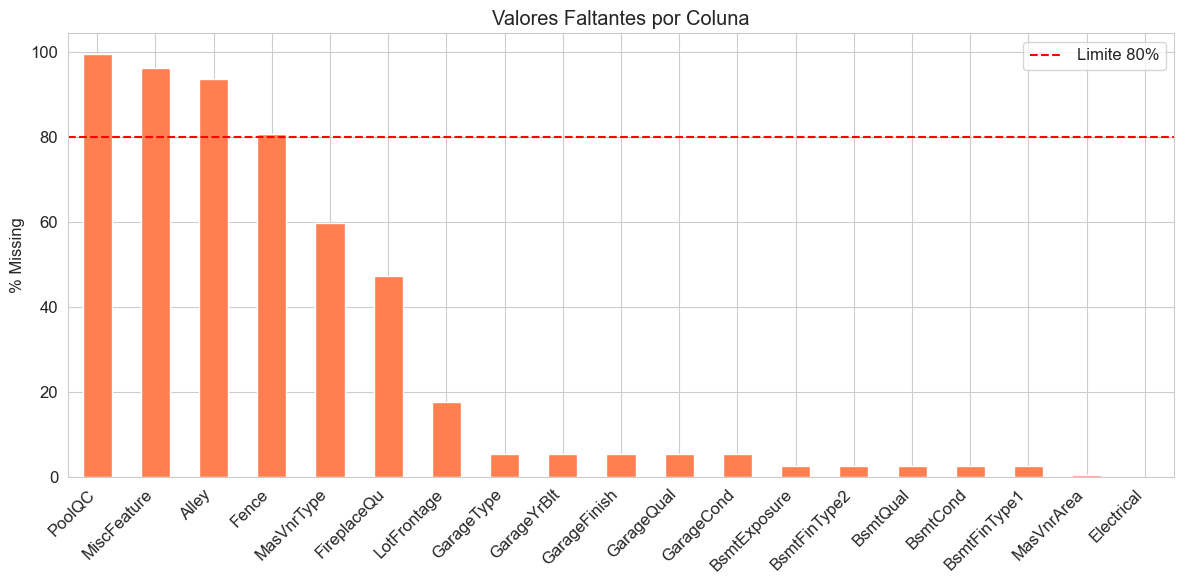

In [21]:
# Visualizar missing values
fig, ax = plt.subplots(figsize=(12, 6))
missing_pct.plot(kind='bar', ax=ax, color='coral', edgecolor='white')
ax.axhline(y=80, color='red', linestyle='--', label='Limite 80%')
ax.set_title('Valores Faltantes por Coluna')
ax.set_ylabel('% Missing')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../reports/missing_values_fase2.png', dpi=150)


In [22]:
# Remover colunas com >80% missing
high_missing = missing_pct[missing_pct > 80].index.tolist()
print(f'Colunas removidas (>80% missing): {high_missing}')

train.drop(columns=high_missing, inplace=True)
test.drop(columns=high_missing, inplace=True)

# Preencher numéricas com mediana
num_cols = train.select_dtypes(include=[np.number]).columns
for col in num_cols:
    if train[col].isnull().any():
        median_val = train[col].median()
        train[col] = train[col].fillna(median_val)
        test[col] = test[col].fillna(median_val)

# Preencher categóricas com 'None'
cat_cols = train.select_dtypes(include=['object']).columns
for col in cat_cols:
    if train[col].isnull().any():
        train[col] = train[col].fillna('None')
        test[col] = test[col].fillna('None')

print(f'Missing restantes: {train.isnull().sum().sum()}')

Colunas removidas (>80% missing): ['PoolQC', 'MiscFeature', 'Alley', 'Fence']
Missing restantes: 0


C:\Users\marlo\AppData\Local\Temp\ipykernel_23836\996093216.py:17: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = train.select_dtypes(include=['object']).columns


## 2. Remover Outliers

**O que são outliers?**
Valores extremos que não representam o padrão dos dados. São como 'pontos fora da curva'.

**Por que remover?**
- Um modelo de ML tenta aprender o padrão geral
- Outliers 'puxam' o modelo para eles, prejudicando a previsão dos casos normais
- É como tentar aprender a média da turma quando um aluno tirou 0 e outro 100

**Regras de remoção (baseadas na EDA da Fase 1):**
- GrLivArea > 4000: casas muito grandes com preço desproporcional
- LotArea > 100000: terrenos gigantes
- TotalBsmtSF > 3000: porões muito grandes

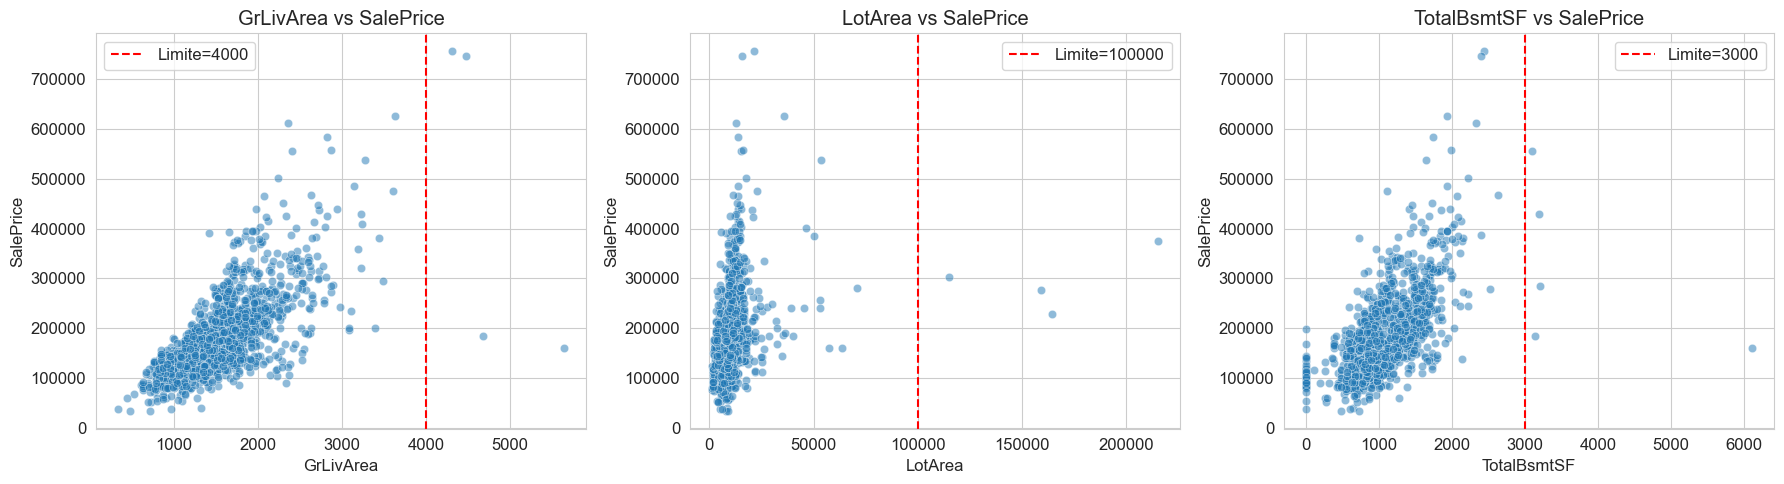

In [23]:
# Visualizar outliers antes de remover
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (col, threshold) in enumerate([('GrLivArea', 4000), ('LotArea', 100000), ('TotalBsmtSF', 3000)]):
    sns.scatterplot(data=train, x=col, y='SalePrice', ax=axes[i], alpha=0.5)
    axes[i].axvline(x=threshold, color='red', linestyle='--', label=f'Limite={threshold}')
    axes[i].set_title(f'{col} vs SalePrice')
    axes[i].legend()

plt.tight_layout()
plt.savefig('../reports/outliers_fase2.png', dpi=150)


In [24]:
# Remover outliers
before = len(train)

outlier_rules = [
    ('GrLivArea', 4000, '>'),
    ('LotArea', 100000, '>'),
    ('TotalBsmtSF', 3000, '>'),
]

for col, threshold, direction in outlier_rules:
    mask = train[col] > threshold
    count = mask.sum()
    print(f'{col} > {threshold}: {count} outliers removidos')
    train = train[~mask]

train = train.reset_index(drop=True)

print(f'\nTotal removidos: {before - len(train)} linhas')
print(f'Dataset agora: {len(train)} linhas')

GrLivArea > 4000: 4 outliers removidos
LotArea > 100000: 4 outliers removidos
TotalBsmtSF > 3000: 3 outliers removidos

Total removidos: 11 linhas
Dataset agora: 1449 linhas


## 3. Log Transform no SalePrice

**O problema:** SalePrice tem distribuição assimétrica (skew=1.55). A maioria das casas tem preço baixo, poucas têm preço muito alto.

**O que é log transform?**
Aplicar o logaritmo nos dados. Isso 'comprime' os valores grandes e 'expande' os pequenos, deixando a distribuição mais simétrica (normal).

**Por que isso importa?**
- Muitos modelos (regressão linear, redes neurais) assumem que os dados seguem distribuição normal
- Dados normais = modelo mais preciso
- É como 'achatar' uma montanha para ver melhor o terreno

**Usamos log1p (log(1+x)) para evitar log(0)**

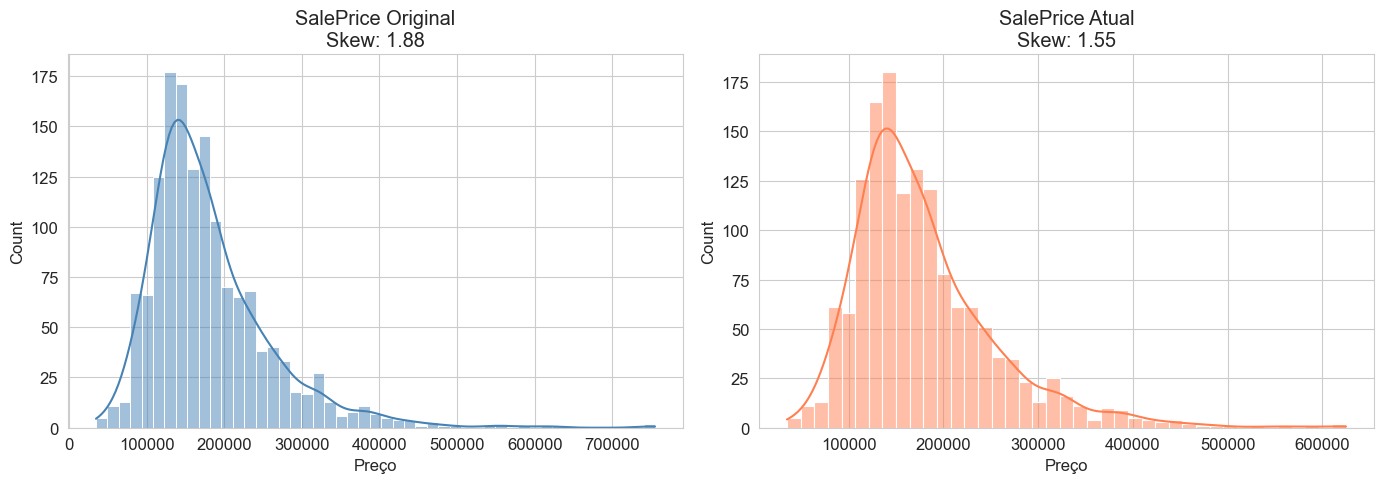

In [25]:
# Comparar distribuição antes e depois do log
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Antes (simulando com os dados originais)
original = pd.read_csv('../data/train.csv')['SalePrice']
sns.histplot(original, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title(f'SalePrice Original\nSkew: {original.skew():.2f}')
axes[0].set_xlabel('Preço')

# Depois
sns.histplot(train['SalePrice'], kde=True, ax=axes[1], color='coral')
axes[1].set_title(f'SalePrice Atual\nSkew: {train["SalePrice"].skew():.2f}')
axes[1].set_xlabel('Preço')

plt.tight_layout()
plt.savefig('../reports/saleprice_before_log.png', dpi=150)


In [26]:
# Aplicar log transform
skew_before = train['SalePrice'].skew()

train['SalePrice'] = np.log1p(train['SalePrice'])

skew_after = train['SalePrice'].skew()

print(f'Skew antes: {skew_before:.4f}')
print(f'Skew depois: {skew_after:.4f}')
print(f'Redução: {(1 - abs(skew_after)/abs(skew_before))*100:.1f}%')

Skew antes: 1.5472
Skew depois: 0.0514
Redução: 96.7%


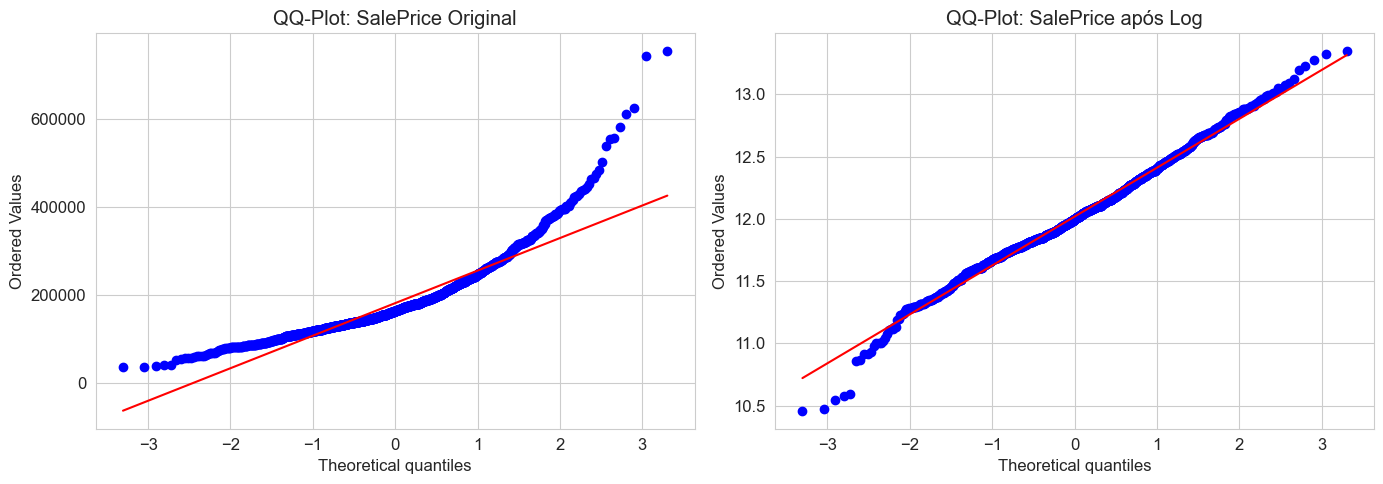

Quanto mais próximo da reta, mais normal é a distribuição!


In [27]:
# Visualizar resultado do log transform
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# QQ-Plot antes (simulado)
from scipy import stats
stats.probplot(original, dist='norm', plot=axes[0])
axes[0].set_title('QQ-Plot: SalePrice Original')

# QQ-Plot depois
stats.probplot(train['SalePrice'], dist='norm', plot=axes[1])
axes[1].set_title('QQ-Plot: SalePrice após Log')

plt.tight_layout()
plt.savefig('../reports/qqplot_saleprice.png', dpi=150)

print('Quanto mais próximo da reta, mais normal é a distribuição!')

## 4. Feature Engineering

**O que é?**
Criar novas features (colunas) a partir das existentes. É como 'inventar' informações que podem ser úteis para o modelo.

**Analogia:**
Se você tem 'largura' e 'comprimento', pode criar 'área'. O modelo pode não descobrir isso sozinho.

**Novas features:**
- **TotalSF**: área total da casa (porão + 1º andar + 2º andar)
- **TotalBath**: total de banheiros (cheio + 0.5*meio)
- **HouseAge**: idade da casa (ano venda - ano construção)
- **RemodAge**: idade da reforma (ano venda - ano reforma)
- **HasPool**: tem piscina? (0 ou 1)
- **HasGarage**: tem garagem? (0 ou 1)

In [28]:
# Criar novas features
for df in [train, test]:
    df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']
    df['TotalBath'] = (df['FullBath'] + 0.5 * df['HalfBath'] +
                       df['BsmtFullBath'] + 0.5 * df['BsmtHalfBath'])
    df['HouseAge'] = df['YrSold'] - df['YearBuilt']
    df['RemodAge'] = df['YrSold'] - df['YearRemodAdd']
    df['HasPool'] = (df['PoolArea'] > 0).astype(int)
    df['HasGarage'] = (df['GarageArea'] > 0).astype(int)

print('Novas features criadas:')
print('- TotalSF (área total)')
print('- TotalBath (banheiros totais)')
print('- HouseAge (idade da casa)')
print('- RemodAge (idade da reforma)')
print('- HasPool (tem piscina)')
print('- HasGarage (tem garagem)')

Novas features criadas:
- TotalSF (área total)
- TotalBath (banheiros totais)
- HouseAge (idade da casa)
- RemodAge (idade da reforma)
- HasPool (tem piscina)
- HasGarage (tem garagem)


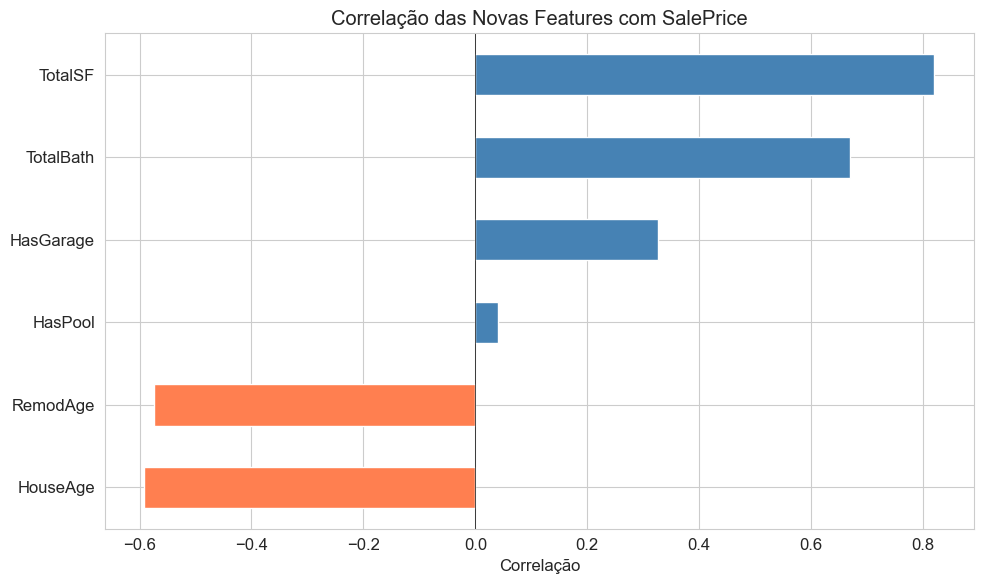

Correlações:
  HouseAge        -0.5917
  RemodAge        -0.5740
  HasPool          0.0414
  HasGarage        0.3258
  TotalBath        0.6704
  TotalSF          0.8206


In [29]:
# Ver correlação das novas features com SalePrice
new_features = ['TotalSF', 'TotalBath', 'HouseAge', 'RemodAge', 'HasPool', 'HasGarage']
correlations = train[new_features + ['SalePrice']].corr()['SalePrice'].drop('SalePrice').sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['coral' if v < 0 else 'steelblue' for v in correlations.values]
correlations.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.set_title('Correlação das Novas Features com SalePrice')
ax.set_xlabel('Correlação')
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.savefig('../reports/new_features_correlation.png', dpi=150)

print('Correlações:')
for feat, corr in correlations.items():
    print(f'  {feat:<15} {corr:>7.4f}')

## 5. Codificar Variáveis Categóricas

**O problema:** Modelos de ML só entendem números. Colunas como 'Neighborhood' (texto) precisam ser convertidas.

**Duas estratégias:**

**Label Encoding** (para variáveis com ordem natural):
- Ex: ExterQual = [Po, Fa, TA, Gd, Ex] → [0, 1, 2, 3, 4]
- Faz sentido: 'Ex' (5) é melhor que 'Po' (1)

**One-Hot Encoding** (para variáveis sem ordem):
- Ex: Neighborhood = [CollgCr, OldTown, ...] → colunas binárias
- Não faz sentido dizer que um bairro é 'maior' que outro

In [30]:
# Label Encoding para variáveis ordinais
ordinal_cols = {
    'ExterQual': ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'ExterCond': ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'BsmtQual': ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'BsmtCond': ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'HeatingQC': ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'KitchenQual': ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'FireplaceQu': ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'GarageQual': ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'GarageCond': ['None', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
}

for col, order in ordinal_cols.items():
    if col in train.columns:
        mapping = {val: i for i, val in enumerate(order)}
        train[col] = train[col].map(mapping).fillna(0).astype(int)
        test[col] = test[col].map(mapping).fillna(0).astype(int)

print(f'Label Encoding aplicado a {len(ordinal_cols)} colunas')

Label Encoding aplicado a 9 colunas


In [31]:
# One-Hot Encoding para categóricas restantes
cat_remaining = train.select_dtypes(include=['object']).columns.tolist()
print(f'One-Hot Encoding para {len(cat_remaining)} colunas:')
print(cat_remaining)

# Combinar train e test para garantir mesmas colunas
combined = pd.concat([train, test], axis=0, ignore_index=True)
combined = pd.get_dummies(combined, columns=cat_remaining, drop_first=True)

# Separar de volta
train = combined.iloc[:len(train)].reset_index(drop=True)
test = combined.iloc[len(train):].reset_index(drop=True)

print(f'\nDataset final: {train.shape[0]} linhas x {train.shape[1]} colunas')
print(f'Test final: {test.shape[0]} linhas x {test.shape[1]} colunas')

One-Hot Encoding para 30 colunas:
['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'Foundation', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'CentralAir', 'Electrical', 'Functional', 'GarageType', 'GarageFinish', 'PavedDrive', 'SaleType', 'SaleCondition']


C:\Users\marlo\AppData\Local\Temp\ipykernel_23836\414136424.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_remaining = train.select_dtypes(include=['object']).columns.tolist()



Dataset final: 1449 linhas x 226 colunas
Test final: 1459 linhas x 226 colunas


## 6. Resumo e Próximos Passos

In [32]:
# Salvar dataset limpo
train.to_csv('../data/train_clean.csv', index=False)
test.to_csv('../data/test_clean.csv', index=False)

print('Dataset salvo!')
print(f'  data/train_clean.csv ({train.shape[0]} x {train.shape[1]})')
print(f'  data/test_clean.csv ({test.shape[0]} x {test.shape[1]})')

Dataset salvo!
  data/train_clean.csv (1449 x 226)
  data/test_clean.csv (1459 x 226)


In [33]:
# Resumo final
print('=' * 50)
print('RESUMO DA FASE 2')
print('=' * 50)
print(f'''
1. Missing values: 4 colunas removidas, resto preenchido
2. Outliers: 11 linhas removidas
3. Log transform: skew {skew_before:.2f} -> {skew_after:.2f} (redução {(1-abs(skew_after)/abs(skew_before))*100:.1f}%)
4. Feature engineering: 6 novas features criadas
5. Encoding: Label Encoding (9) + One-Hot Encoding ({len(cat_remaining)})
6. Dataset final: {train.shape[0]} linhas x {train.shape[1]} colunas

PROXIMOS PASSOS (Fase 3):
- Treinar modelo baseline (Regressão Linear)
- Treinar Random Forest
- Comparar métricas (RMSE, R²)
- Cross-validation
''')

RESUMO DA FASE 2

1. Missing values: 4 colunas removidas, resto preenchido
2. Outliers: 11 linhas removidas
3. Log transform: skew 1.55 -> 0.05 (redução 96.7%)
4. Feature engineering: 6 novas features criadas
5. Encoding: Label Encoding (9) + One-Hot Encoding (30)
6. Dataset final: 1449 linhas x 226 colunas

PROXIMOS PASSOS (Fase 3):
- Treinar modelo baseline (Regressão Linear)
- Treinar Random Forest
- Comparar métricas (RMSE, R²)
- Cross-validation

